<a href="https://colab.research.google.com/github/vishnuiyer23ug-stack/computational-statistics-course-4/blob/main/Class_06_polynomial_regression_bias_variance_tradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Polynomial regression
Let's try loading a dataset a dataset from Kaggle. To do this, you will need to [create a legacy API key from Kaggle](https://www.kaggle.com/settings). This will download a kaggle.json file.

In [231]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vishnuiy","key":"486d6432bba091fa3d92dbda2f2ebdd4"}'}

In [232]:
# Change the permissions of the kaggle.json file such that only you can read/write the file.
# This is to prevent someone else from modifying the file.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [233]:
!pip install -q kaggle # Install that Kaggle package to interact with Kaggle's datasets; pip is python's package manager

In [234]:
!kaggle datasets download -d mirajdeepbhandari/polynomial-regression

Dataset URL: https://www.kaggle.com/datasets/mirajdeepbhandari/polynomial-regression
License(s): CC0-1.0
polynomial-regression.zip: Skipping, found more recently modified local copy (use --force to force download)


In [235]:
!unzip polynomial-regression.zip

Archive:  polynomial-regression.zip
replace Ice_cream selling data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [236]:
# Import necessary packages
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import scale, PolynomialFeatures
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.metrics import PredictionErrorDisplay

In [237]:
os.listdir() # Look for the files/directories within the current directory

['.config',
 'kaggle (1).json',
 'kaggle.json',
 'polynomial-regression.zip',
 'Ice_cream selling data.csv',
 'sample_data']

The Ice_cream selling data.csv is available!

In [238]:
data = pd.read_csv("Ice_cream selling data.csv") # Read the csv file into a pandas dataframe
type(data)

pandas.core.frame.DataFrame

In [239]:
data.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [330]:
data.shape

(49, 2)

In [331]:
data.info() # Gives basic information about the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


In [332]:
data.describe() # Gives basic statistics about the columns of the dataframe

,Temperature (°C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


In [333]:
X = data.iloc[:, :-1]/5 # We are extracting the features and response. The first : tells python to take all the rows, and we take it up until the last column (i.e., :-1)
y = data.iloc[:, -1] # This tells python to take only the last column.

In [334]:
# Fitting the data to a linear model

In [335]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [336]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [337]:
model.score(X_train, y_train) # Training R^2. It's really poor

0.026645247696274632

In [338]:
predict = model.predict(X_test)

In [339]:
r2_score(y_test,predict) # This means that our model does a worse job at predicting the response variable than the mean.


0.013527080157335392

In [340]:
model.coef_, model.intercept_

(array([-3.71097197]), np.float64(16.708758190473553))

In [341]:
x_vals = np.arange(-1,1,0.1)

In [342]:
y_vals = model.coef_*x_vals + model.intercept_

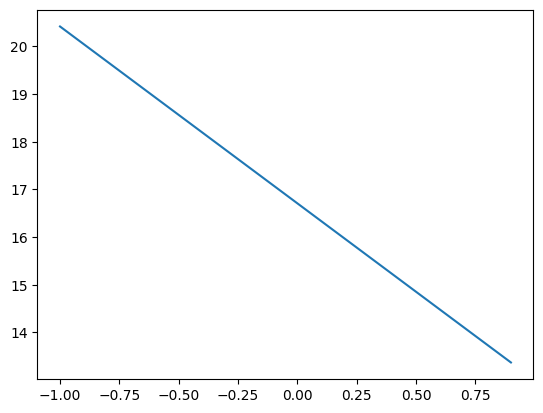

In [343]:
plt.plot(x_vals,y_vals)

In [344]:
y_mean = np.mean(y)
y_mean = np.array([y_mean for i in range(len(x_vals))])

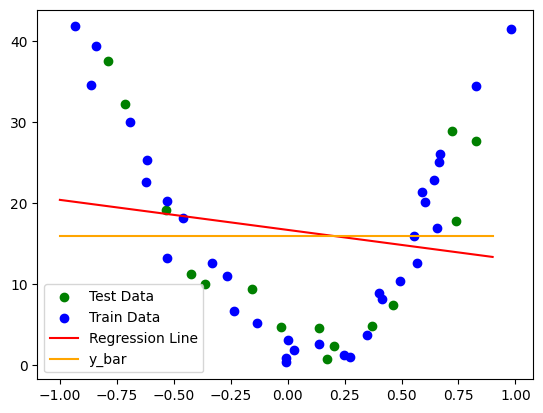

In [345]:
plt.scatter(X_test,y_test,color="green", label = "Test Data") # For the training data, the mean is a better estimate than the regression line
plt.scatter(X_train,y_train,color="blue", label ="Train Data") # For the testing data, the regression model is a marginally better estimate than the mean.
plt.plot(x_vals,y_vals, color="red",label = "Regression Line") # The regression model
plt.plot(x_vals,y_mean,color="orange",label = "y_bar")
plt.legend() # The mean of the data


In [310]:
# Since the linear model was so bad, we now switch to a polynomial model. This is still linear in parameters, but
# it is polynomial in X (i.e., the features)

In [311]:
poly_features = PolynomialFeatures(degree=6) # degree determines the degree of the features (self-explanatory)
X_transformed = poly_features.fit_transform(X)
X_transformed # This is the features vector. The first column is 1 as usual. The second column is X1 which is the same as before.
# The third column gives us the square of X1 (and thus X1^2) giving us the polynomial in X form. The e+01 means *10^1.

array([[ 1.00000000e+00, -9.32452535e-01,  8.69467731e-01,
        -8.10737390e-01,  7.55974135e-01, -7.04909999e-01,
         6.57295116e-01],
       [ 1.00000000e+00, -8.63311889e-01,  7.45307418e-01,
        -6.43432755e-01,  5.55483148e-01, -4.79555206e-01,
         4.14005711e-01],
       [ 1.00000000e+00, -8.42796953e-01,  7.10306704e-01,
        -5.98644326e-01,  5.04535614e-01, -4.25221078e-01,
         3.58375029e-01],
       [ 1.00000000e+00, -7.89932218e-01,  6.23992909e-01,
        -4.92912102e-01,  3.89367150e-01, -3.07573656e-01,
         2.42962341e-01],
       [ 1.00000000e+00, -7.15710743e-01,  5.12241868e-01,
        -3.66617008e-01,  2.62391731e-01, -1.87796581e-01,
         1.34408031e-01],
       [ 1.00000000e+00, -6.91142340e-01,  4.77677734e-01,
        -3.30143306e-01,  2.28176017e-01, -1.57702106e-01,
         1.08994603e-01],
       [ 1.00000000e+00, -6.21688024e-01,  3.86495999e-01,
        -2.40279934e-01,  1.49379158e-01, -9.28672333e-02,
         5.7734446

In [312]:
# Now we run the same code for running the regression but on X_transformed

In [346]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size = 0.2, random_state = 42)
model = LinearRegression()
model.fit(X_train,y_train)
train_r2 = model.score(X_train, y_train) # Training R^2 is now super high

In [347]:
# Predicted values for the train data
train_predict = model.predict(X_train)

In [348]:
# Predcted values for the test data
test_predict = model.predict(X_test)
test_r2 = model.score(X_test,y_test) # Test R^2 is also pretty high

In [349]:
train_error = mean_squared_error(y_train, train_predict)
print(train_error)
test_error = mean_squared_error(y_test, test_predict)
print(test_error)
print(train_r2)
print(test_r2)

# We do this exercise to see how the MSE changes as we change the degree of X in the model. As we increase the degrees, the model becomes
# more and more specific to the training data, thus leading to overfitting. Every time we increase the degree, the MSE of the train data
# reduces and that of the test data increases. As we increase the degree, the train R2 increases and the test R2 falls.

1.4880445989647642
758115160.615813
0.9903011953674277
-7996766.7725844765


/tmp/ipython-input-3908559178.py:24: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


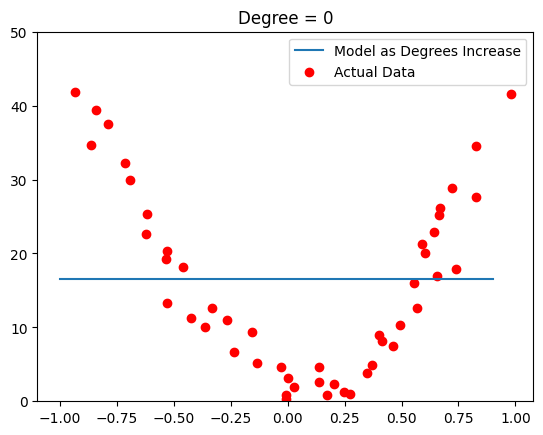

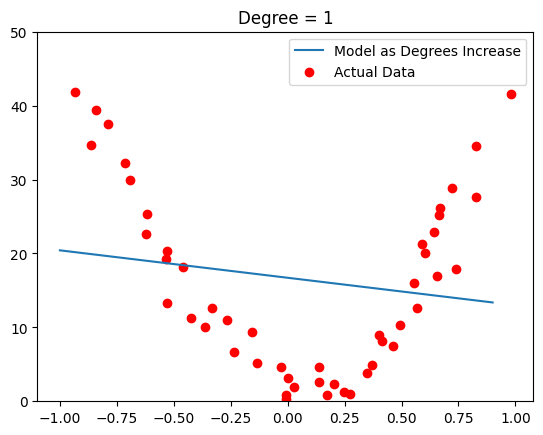

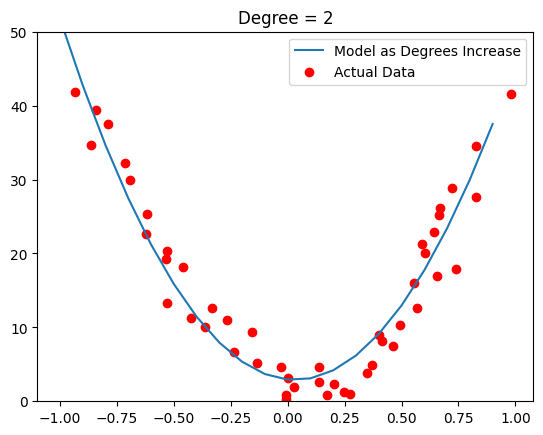

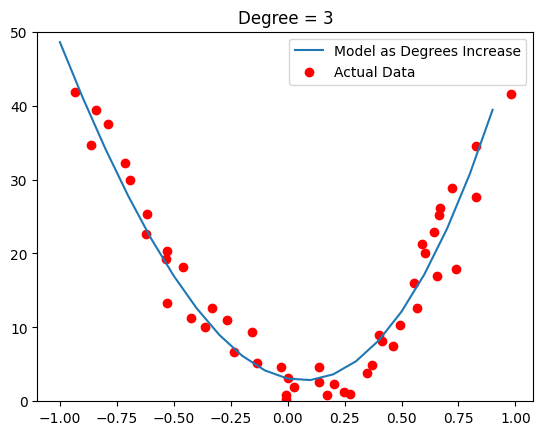

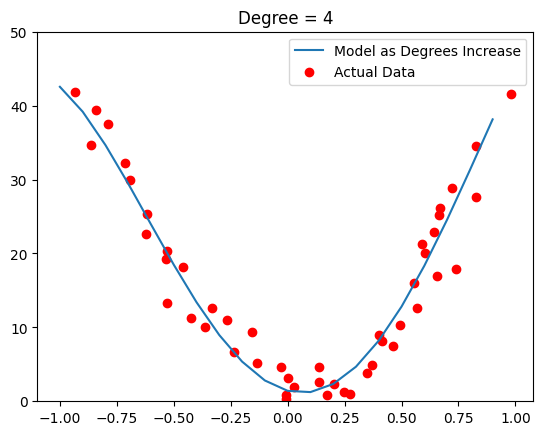

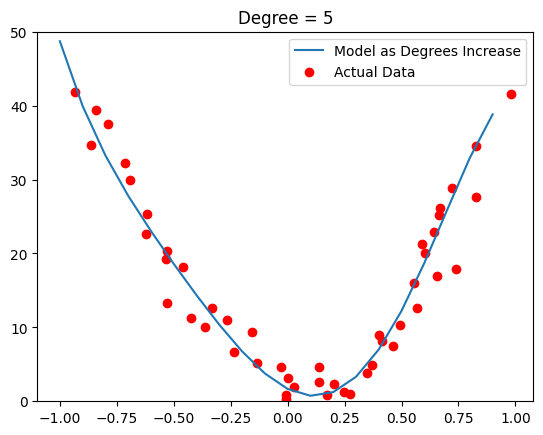

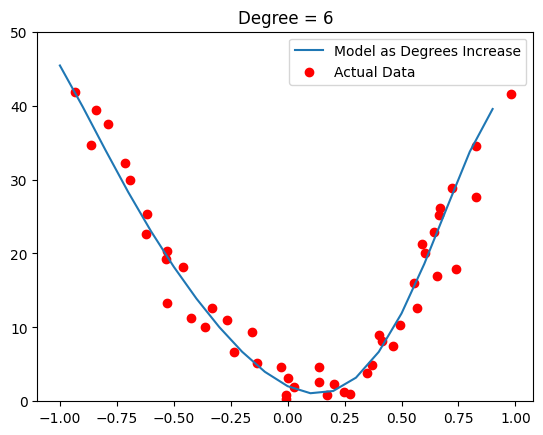

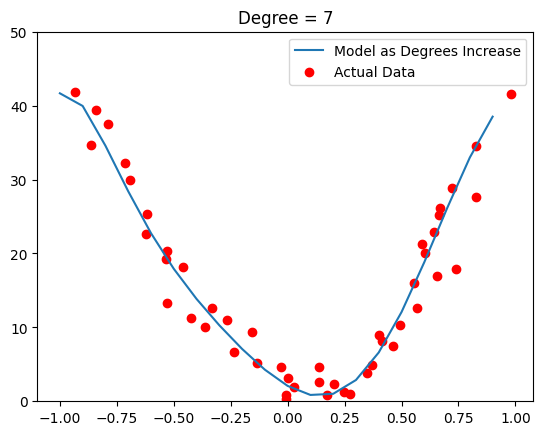

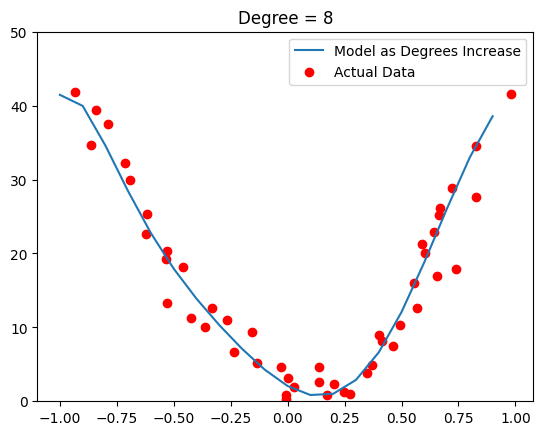

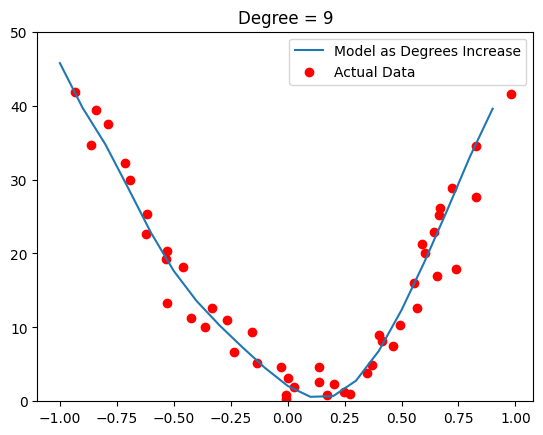

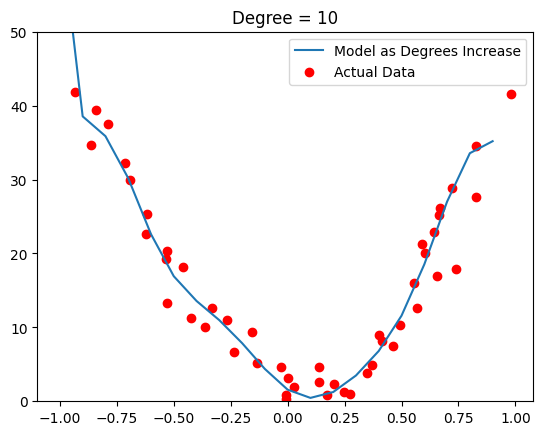

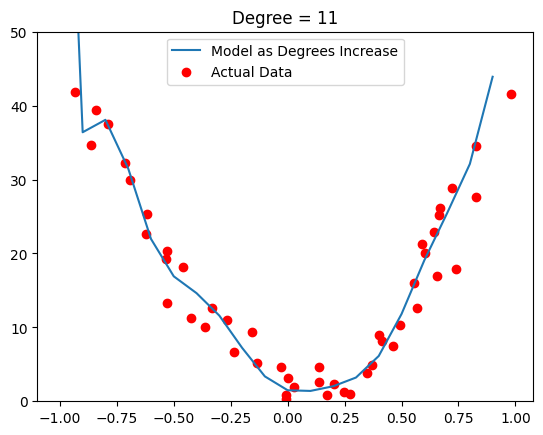

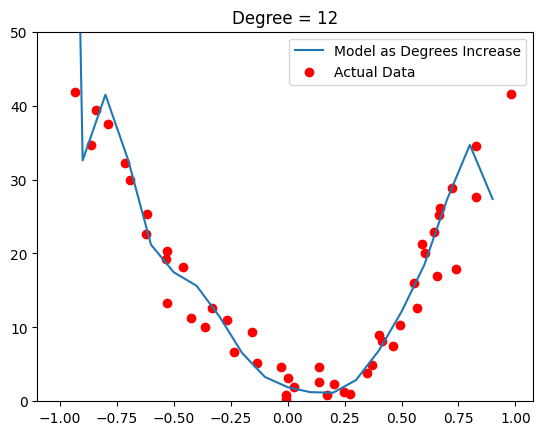

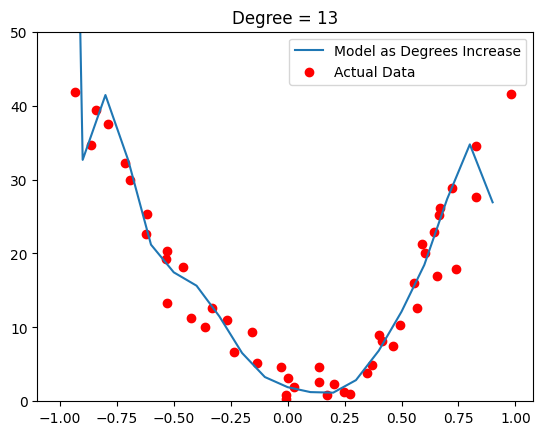

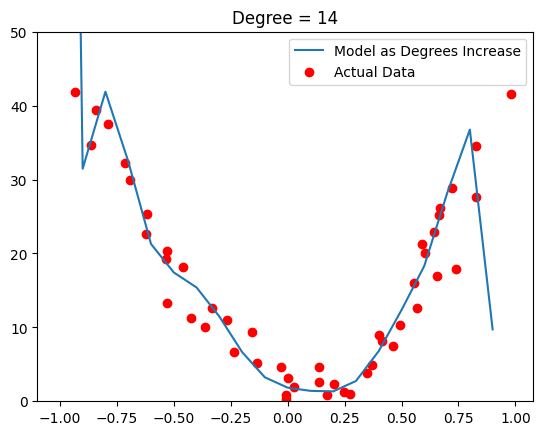

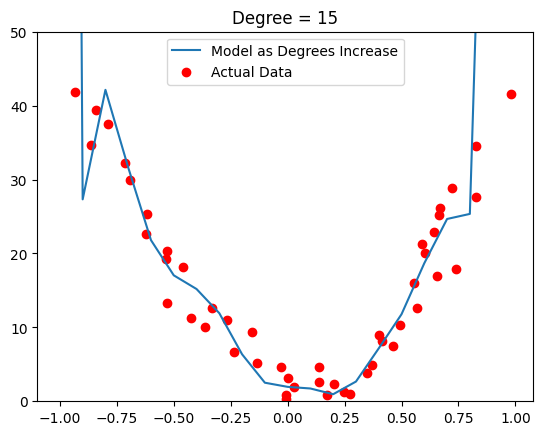

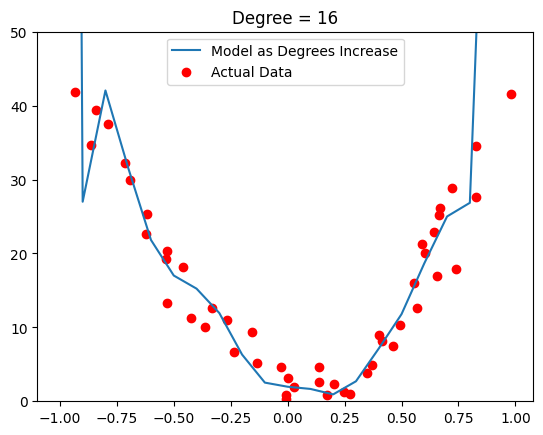

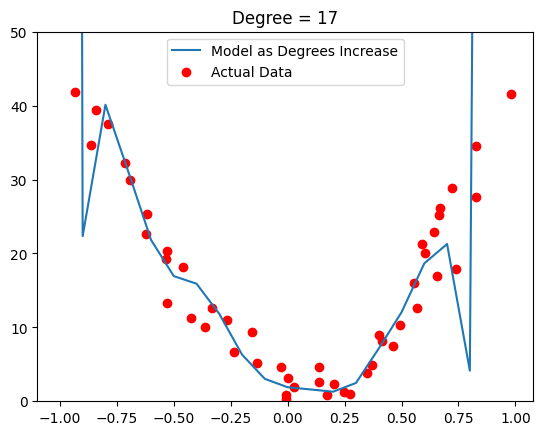

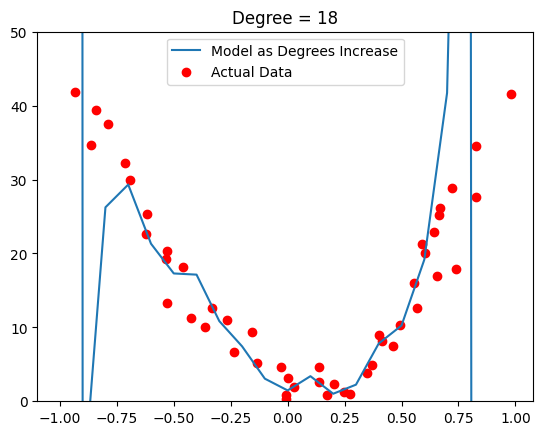

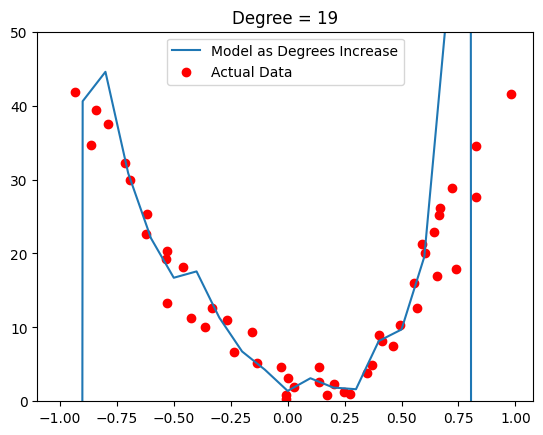

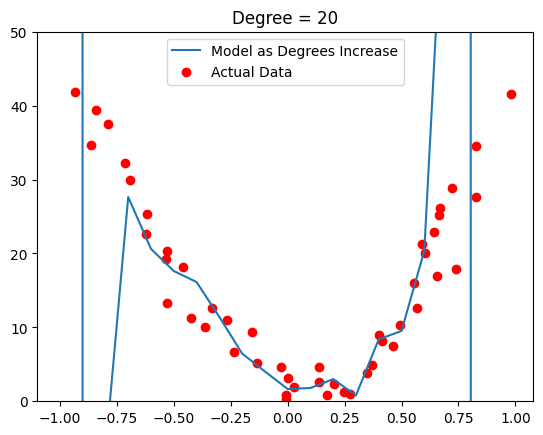

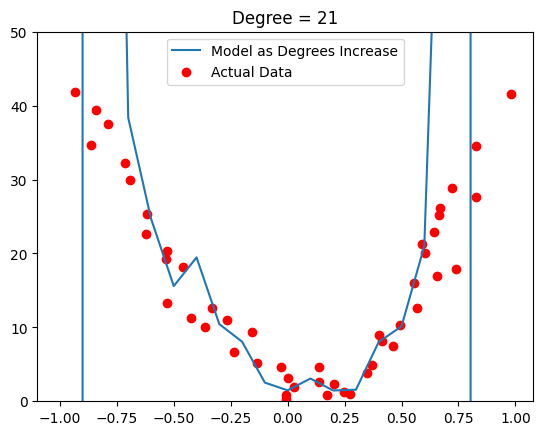

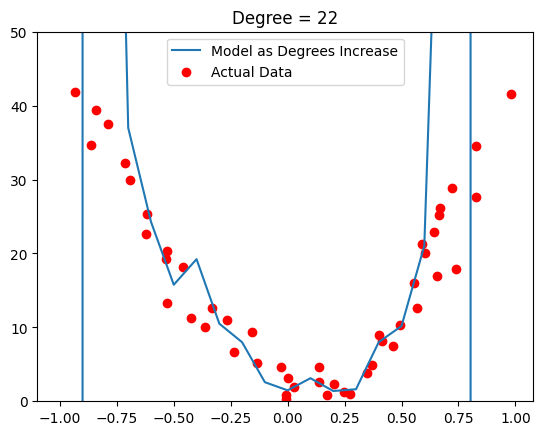

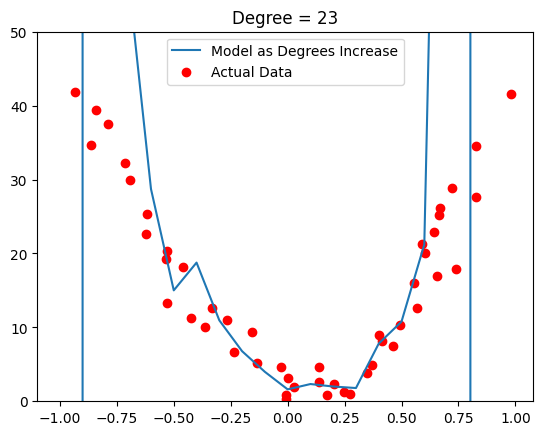

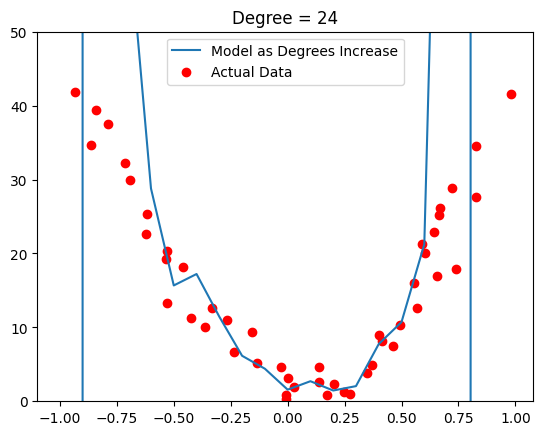

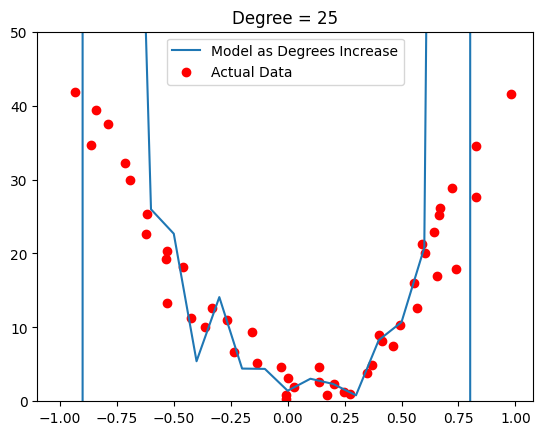

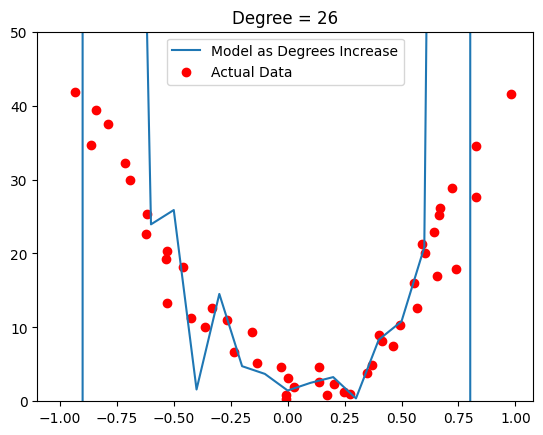

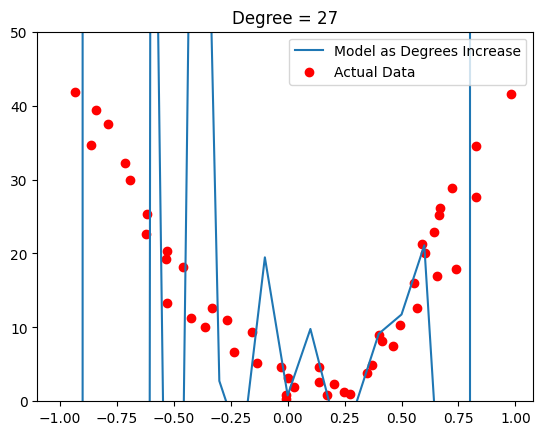

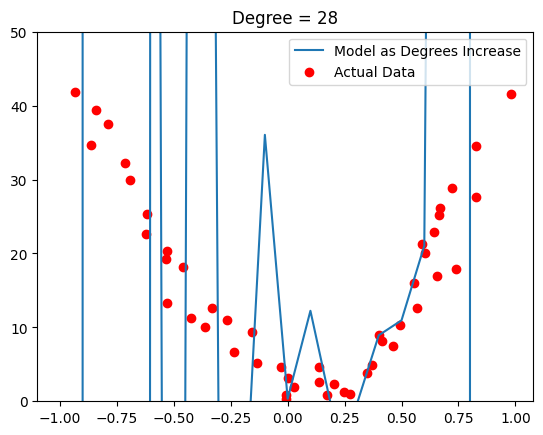

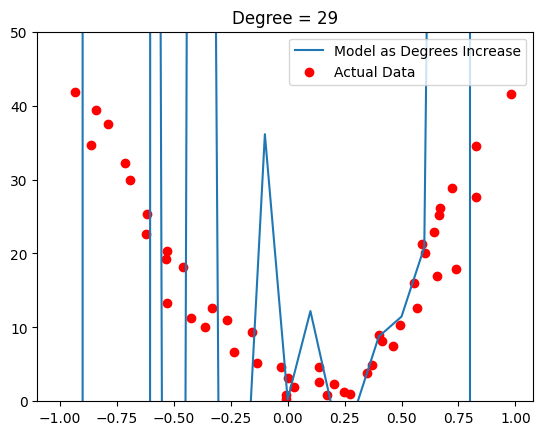

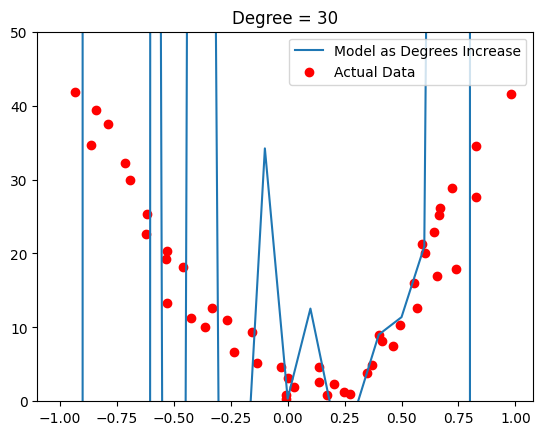

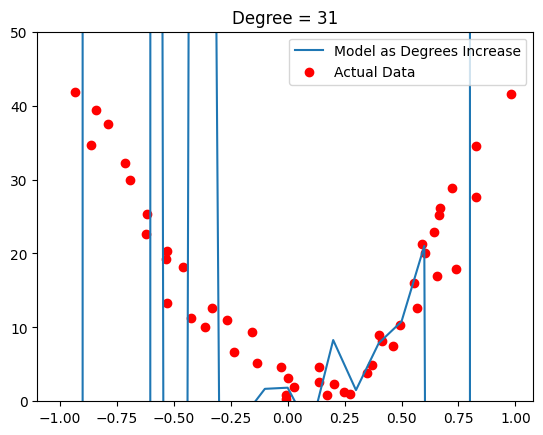

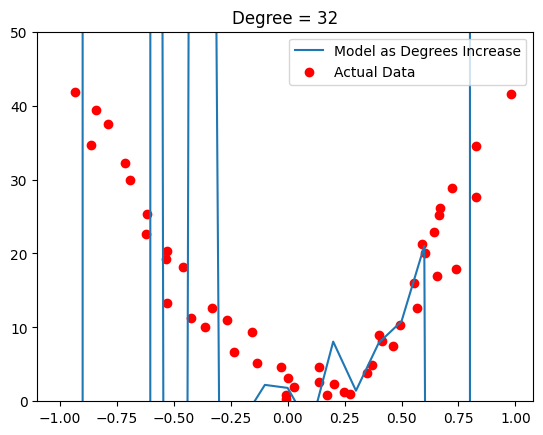

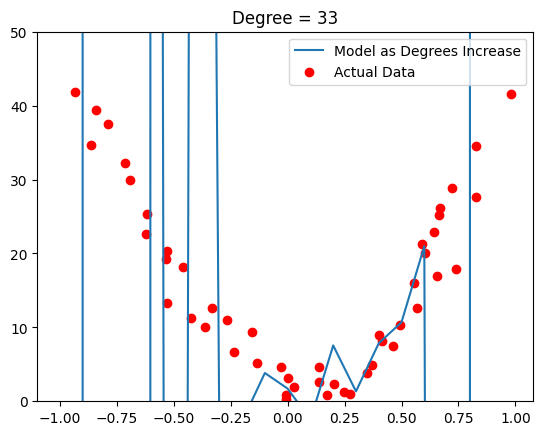

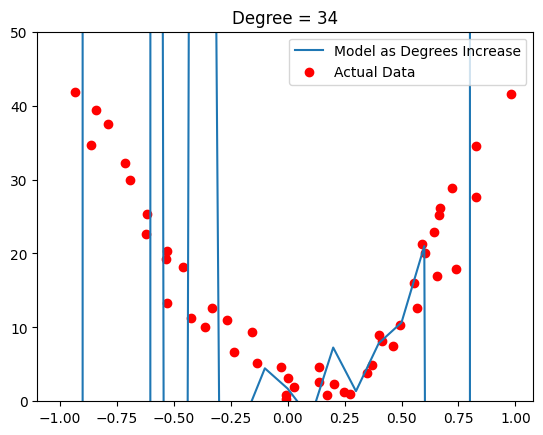

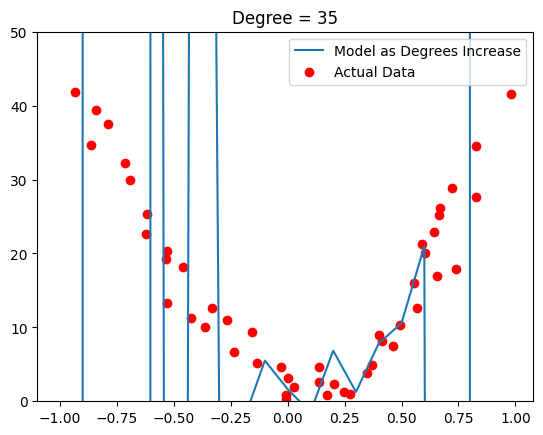

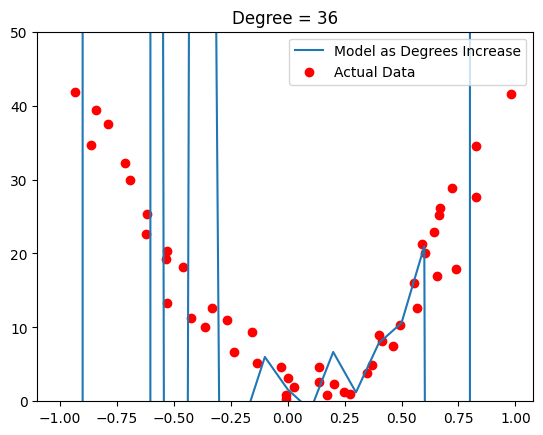

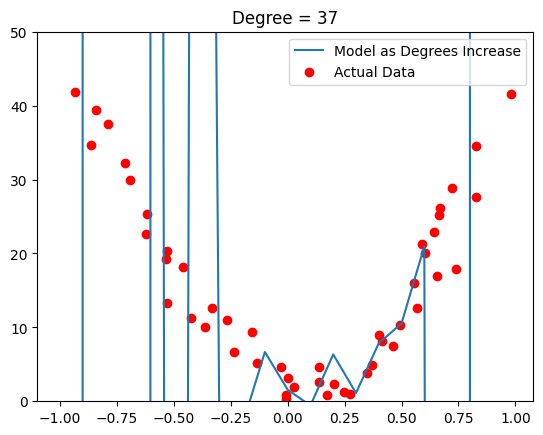

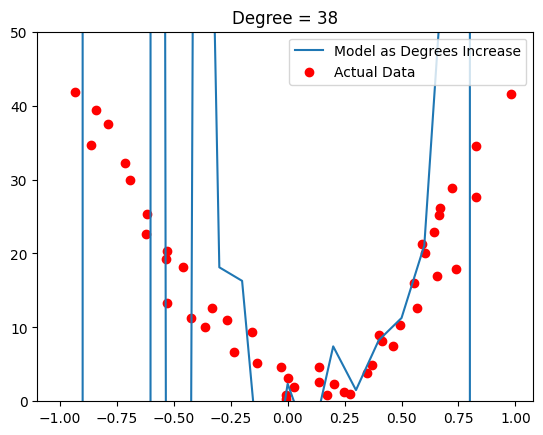

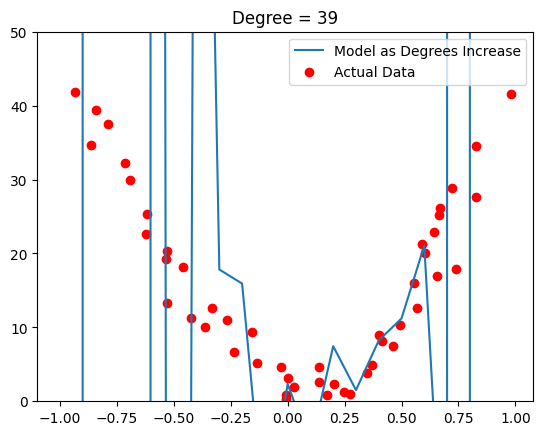

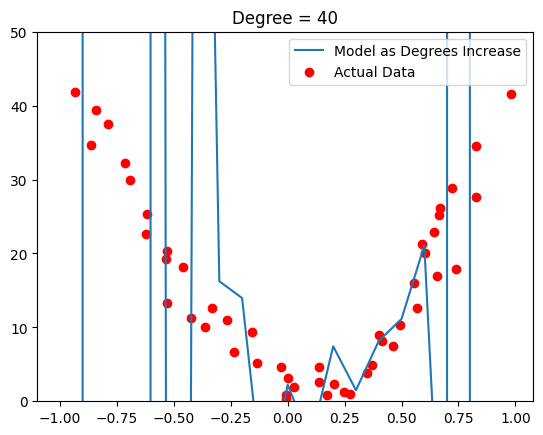

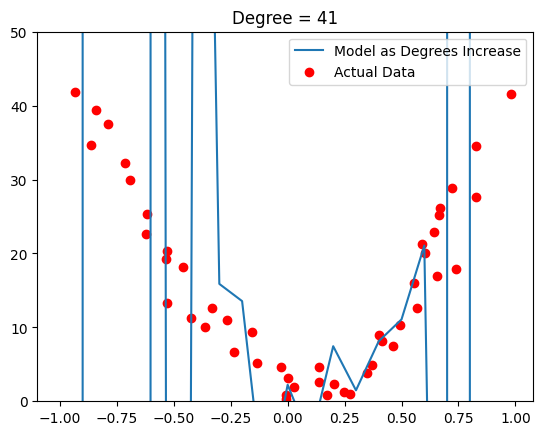

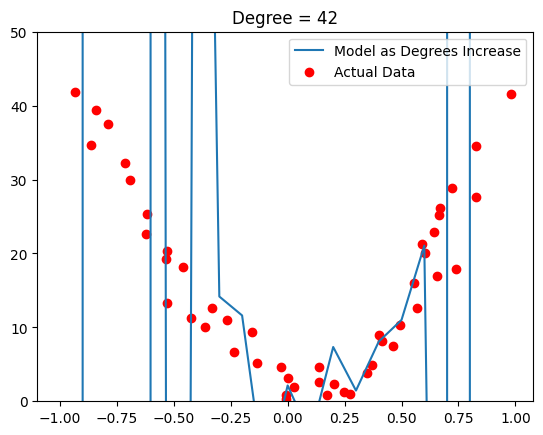

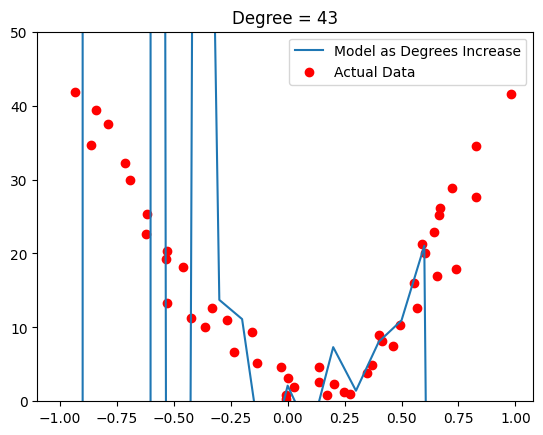

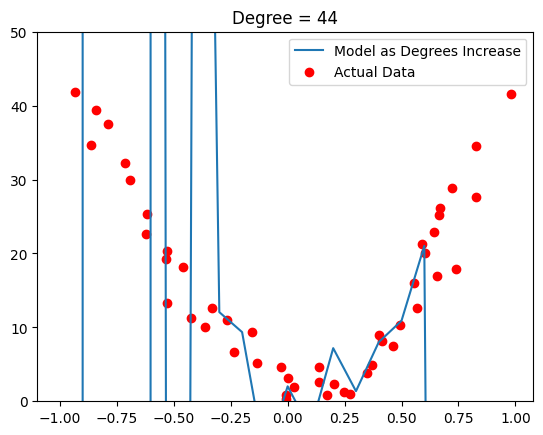

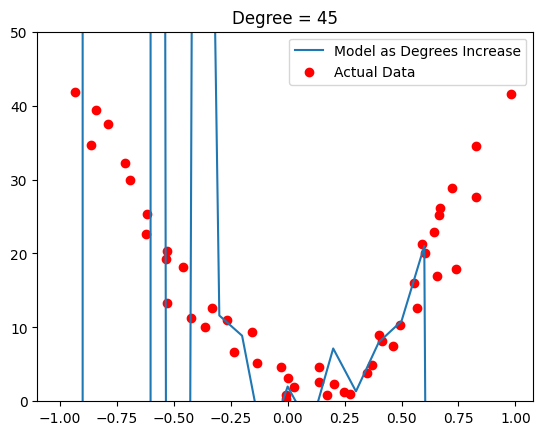

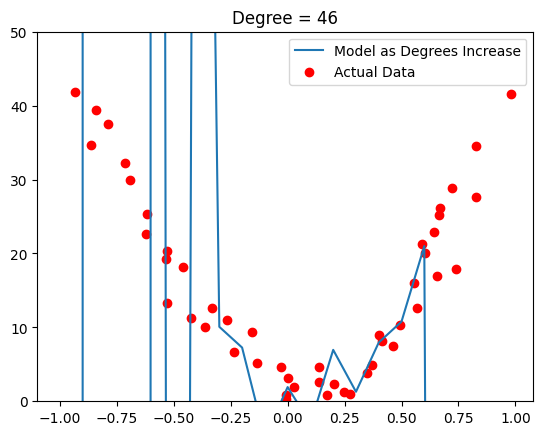

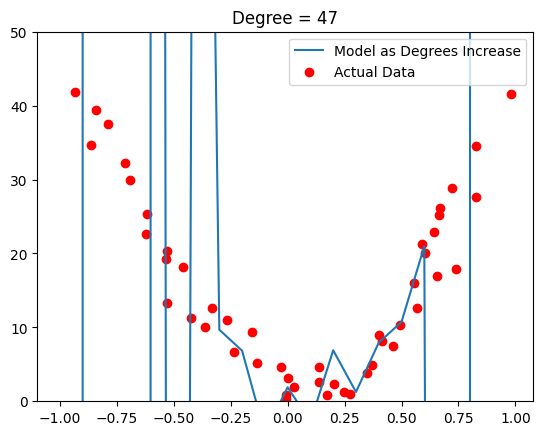

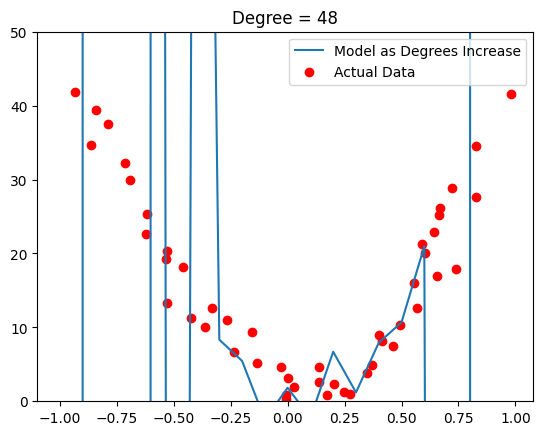

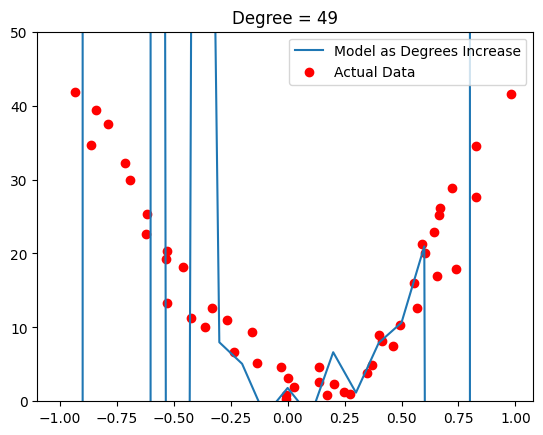

In [356]:
n = 50
train_r2 = np.zeros(n)
test_r2 = np.zeros(n)
train_error = np.zeros(n)
test_error = np.zeros(n)

x_vals = pd.DataFrame(x_vals, columns=["Temperatures"])

for i in range(n):
  poly_features = PolynomialFeatures(degree=i) # degree determines the degree of the features (self-explanatory)
  X_transformed = poly_features.fit_transform(X)
  x_vals_transformed = poly_features.fit_transform(x_vals)
  X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size = 0.3, random_state = 42)
  model = LinearRegression()
  model.fit(X_train,y_train)
  train_r2[i] = model.score(X_train, y_train)
  train_predict = model.predict(X_train)
  test_predict = model.predict(X_test)
  test_r2[i] = model.score(X_test,y_test)
  train_error[i] = mean_squared_error(y_train, train_predict)
  test_error[i] = mean_squared_error(y_test, test_predict)
  y_pred_transformed = model.predict(x_vals_transformed) # Helps us see what the model is predicting for values of x that are not in our dataset
  residuals = y - model.predict(X_transformed)
  plt.figure()

  plt.plot(x_vals,y_pred_transformed, label = "Model as Degrees Increase")
  plt.scatter(X,y,color="red", label = "Actual Data")
  #plt.scatter(X,residuals,color="green")
  plt.title(f"Degree = {i}")
  plt.ylim(0,50)
  plt.legend()


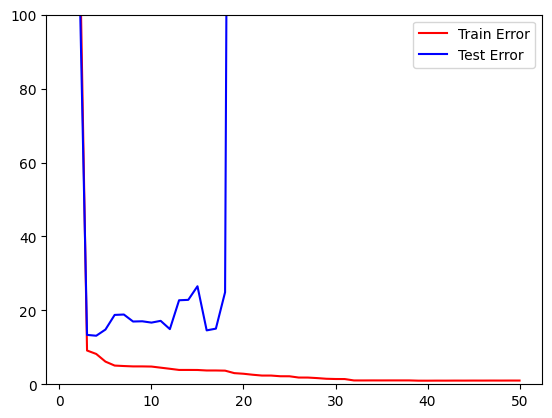

In [318]:
i = np.arange(1,n+1,1)
plt.plot(i,train_error,color="red", label = "Train Error")
plt.plot(i,test_error,color="blue", label = "Test Error")
plt.ylim((0,100))
plt.legend()

# Why is the train error going up?
# Look at the next cell for the info

In [270]:
type(X.iloc[0,0])
# We can see here that the string can only hold 64 bits of info (think 64 digits except one bit is the sign of the number, 11 bits
# for the exponent and 52 for the mantissa (part of the logarithm after the decimal)). As we increase the number of degrees,
# the range of our values of X increases from (-5,5) for X to [0, 5^50) for X^50. 5^50 is approximately 10^35 using logs (base 10).
# The resolution here will be 10^35 x 10^-16 = 10^19. We lose out on all information that is more granular than 10^19 away. The reason
# for the 10^-16 is because when we convert the 52 bits for the mantissa into a decimal point format, we get 10^-16.

# Interestingly, if we divide the X values that we originally extracted from the dataset by 5, we restrct the range of X to (-1,1).
# Now, no matter how much we increase the degree of X, our range will either be (-1,1) or [0,1). Try dividing the X values by 5
# at the very start of the code, and also change x_vals to [-1,1,0.1] and run the graphs again.
# This will change everything up and make it just as expected.

# To make things break, change X to not being divided by 5. ALso change x_vals back to [-5,5,0.1].

numpy.float64

In [319]:
train_r2

array([0.        , 0.02664525, 0.94014573, 0.9462588 , 0.95982347,
       0.96683564, 0.96765889, 0.96831783, 0.96831924, 0.96857994,
       0.97055585, 0.97252378, 0.97458582, 0.97458611, 0.97466656,
       0.9755422 , 0.97554663, 0.97583865, 0.98023215, 0.98133947,
       0.98309531, 0.98453431, 0.98454038, 0.98575661, 0.98581793,
       0.98806329, 0.98809765, 0.98903385, 0.99022618, 0.99066503,
       0.99073565, 0.9931954 , 0.99321184, 0.99314985, 0.99317602,
       0.99313958, 0.99314657, 0.9931396 , 0.99360111, 0.99362078,
       0.9935299 , 0.99355117, 0.99347196, 0.99349469, 0.99343098,
       0.993455  , 0.99340426, 0.99342919, 0.99339117, 0.99341635])

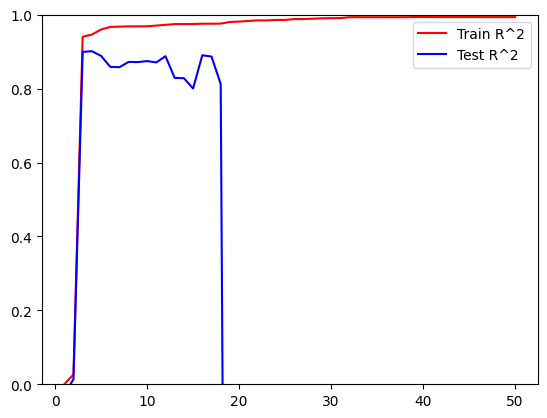

In [320]:
i = np.arange(1,n+1,1)
plt.plot(i,train_r2,color="red", label ="Train R^2")
plt.plot(i,test_r2,color="blue", label = "Test R^2")
plt.ylim((0,1))
plt.legend()